# 07 — Ablation study

Measures each module's contribution and compares weighting schemes.

- **A1-A3:** remove one module at a time; the drop in F1 is that module's contribution.
- **A4:** compare weighting schemes — equal, severity (fixed 0.3/0.5/0.2), adaptive (Layer 2 confidence weighting), and max (fail if any dimension is bad).

Method: build labelled batches (clean should PASS, corrupted should FAIL), with corrupted batches carrying one fault type each (anomaly / drift / missing). Score the PASS/FAIL decision against the true label with F1.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from preprocessing import temporal_split
import module2_drift as m2, ablation as ab
DATA_PATH = '../data/HI-Small_Trans.csv'

## Fit what the framework needs and build labelled batches

In [2]:
cols=['Timestamp','Amount Paid','Amount Received','Receiving Currency','Payment Currency','Payment Format']
df = pd.read_csv(DATA_PATH, usecols=cols)
ref, _ = temporal_split(df, reference_days=3, max_days=10)
ref_pool = ref.reset_index(drop=True)
reference = ref_pool.sample(50_000, random_state=42).reset_index(drop=True)
ref_log = np.log1p(reference['Amount Paid'].clip(lower=0))
Xd, yd = m2.build_drift_dataset(reference, ref_pool, rates=[0.05,0.10], batch_size=20_000, n_per_rate=12, seed=42)
drift_clf = m2.train_drift_classifier(Xd, yd)
fitted = dict(ref_log_mean=ref_log.mean(), ref_log_std=ref_log.std(), drift_clf=drift_clf)
labelled = ab.build_labelled_scores(reference, ref_pool, fitted, n_each=12, seed=42)
print('batches:', len(labelled), '(clean + anomaly/drift/missing corruptions)')

batches: 48 (clean + anomaly/drift/missing corruptions)


## Sanity: severity of each single fault type
Each fault should score high on its own dimension.

In [3]:
rows=[]
for kind in ['anomaly','drift','missing']:
    base = ref_pool.sample(20_000, random_state=1).reset_index(drop=True)
    s = ab.compute_scores(ab.corrupt_batch(base, kind, seed=3), reference, fitted)
    rows.append([kind, round(s['anomaly'],2), round(s['drift'],2), round(s['missing'],2)])
pd.DataFrame(rows, columns=['fault type','anomaly','drift','missing'])

,fault type,anomaly,drift,missing
0,anomaly,1.00,0.89,0.0
1,drift,0.01,0.89,0.0
2,missing,0.00,0.15,1.0


## Ablation results (A0-A4)

In [4]:
res = ab.run_ablation(labelled)
res.round(3)

,experiment,f1,accuracy
0,A0 Full framework (max),0.986,0.979
1,A1 Remove Module 1 (anomaly),0.986,0.979
2,A2 Remove Module 2 (drift),0.800,0.750
3,A3 Remove Module 3 (missing),0.787,0.729
4,A4 Weighting: equal,0.500,0.500
5,A4 Weighting: severity,0.500,0.500
6,A4 Weighting: adaptive,0.500,0.500
7,A4 Weighting: max,0.986,0.979


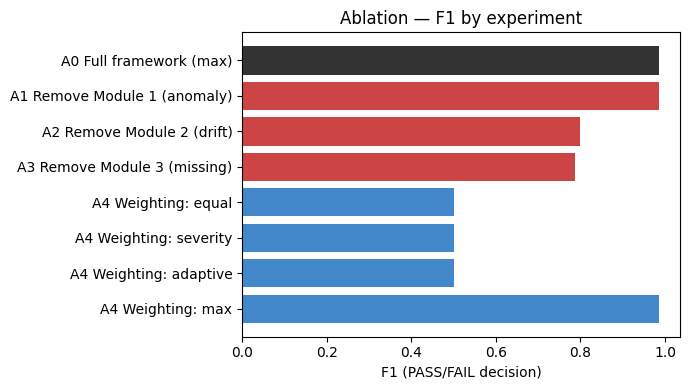

In [5]:
plt.figure(figsize=(7,4))
colors=['#333']+['#c44']*3+['#48c']*4
plt.barh(res['experiment'][::-1], res['f1'][::-1], color=colors[::-1])
plt.xlabel('F1 (PASS/FAIL decision)'); plt.title('Ablation — F1 by experiment')
plt.tight_layout(); plt.savefig('../results/ablation_f1.png', dpi=120); plt.show()

## Reading the results
- **Remove Module 1 (anomaly): no drop.** Module 1 is redundant with Module 2 on this data — an extreme value anomaly is also a distributional shift, so the drift module catches it too. A real insight about amount-driven financial data.
- **Remove Module 2 or Module 3: F1 drops.** Both contribute; Module 3 (missing) is the only module that catches missing-value faults.
- **A4: averaging schemes (equal / severity / adaptive) score far lower than max.** Averaging dilutes a single-dimension fault below the threshold, so those batches wrongly pass. The max rule (fail if any dimension is bad) is the correct gate semantics. This confirms the caveat in the literature review: RABEM's confidence weighting suits combining same-task models, not different quality dimensions where any single fault should fail the batch.
- **Implication:** the confidence-weighted layer is useful for interpretable per-dimension severity and purpose-based prioritisation, but the final gate decision should use a max/OR rule.